step-1:Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

step-2:

In [2]:
df = pd.read_csv("./wineQT.csv")
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

step-3: Analyzing The Data

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


step-4:

In [4]:
df.columns.tolist()

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality',
 'Id']

In [5]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

step-5:FINDING DUPLICATES

In [ ]:
df.duplicated().sum()

np.int64(0)

STEP-6: UNIVARIATE ANALYSIS

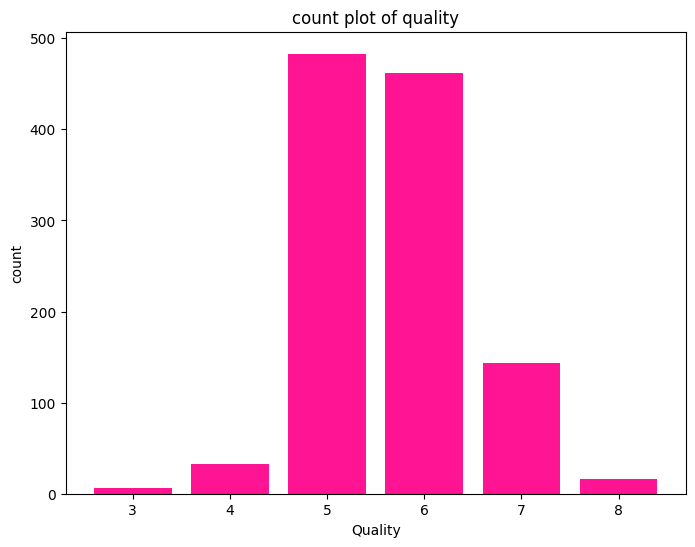

In [8]:
quality_counts = df['quality'].value_counts()

plt.figure(figsize=(8,6))

plt.bar(quality_counts.index, quality_counts, color='deeppink')

plt.title('count plot of quality')
plt.xlabel('Quality')
plt.ylabel('count')
plt.show()

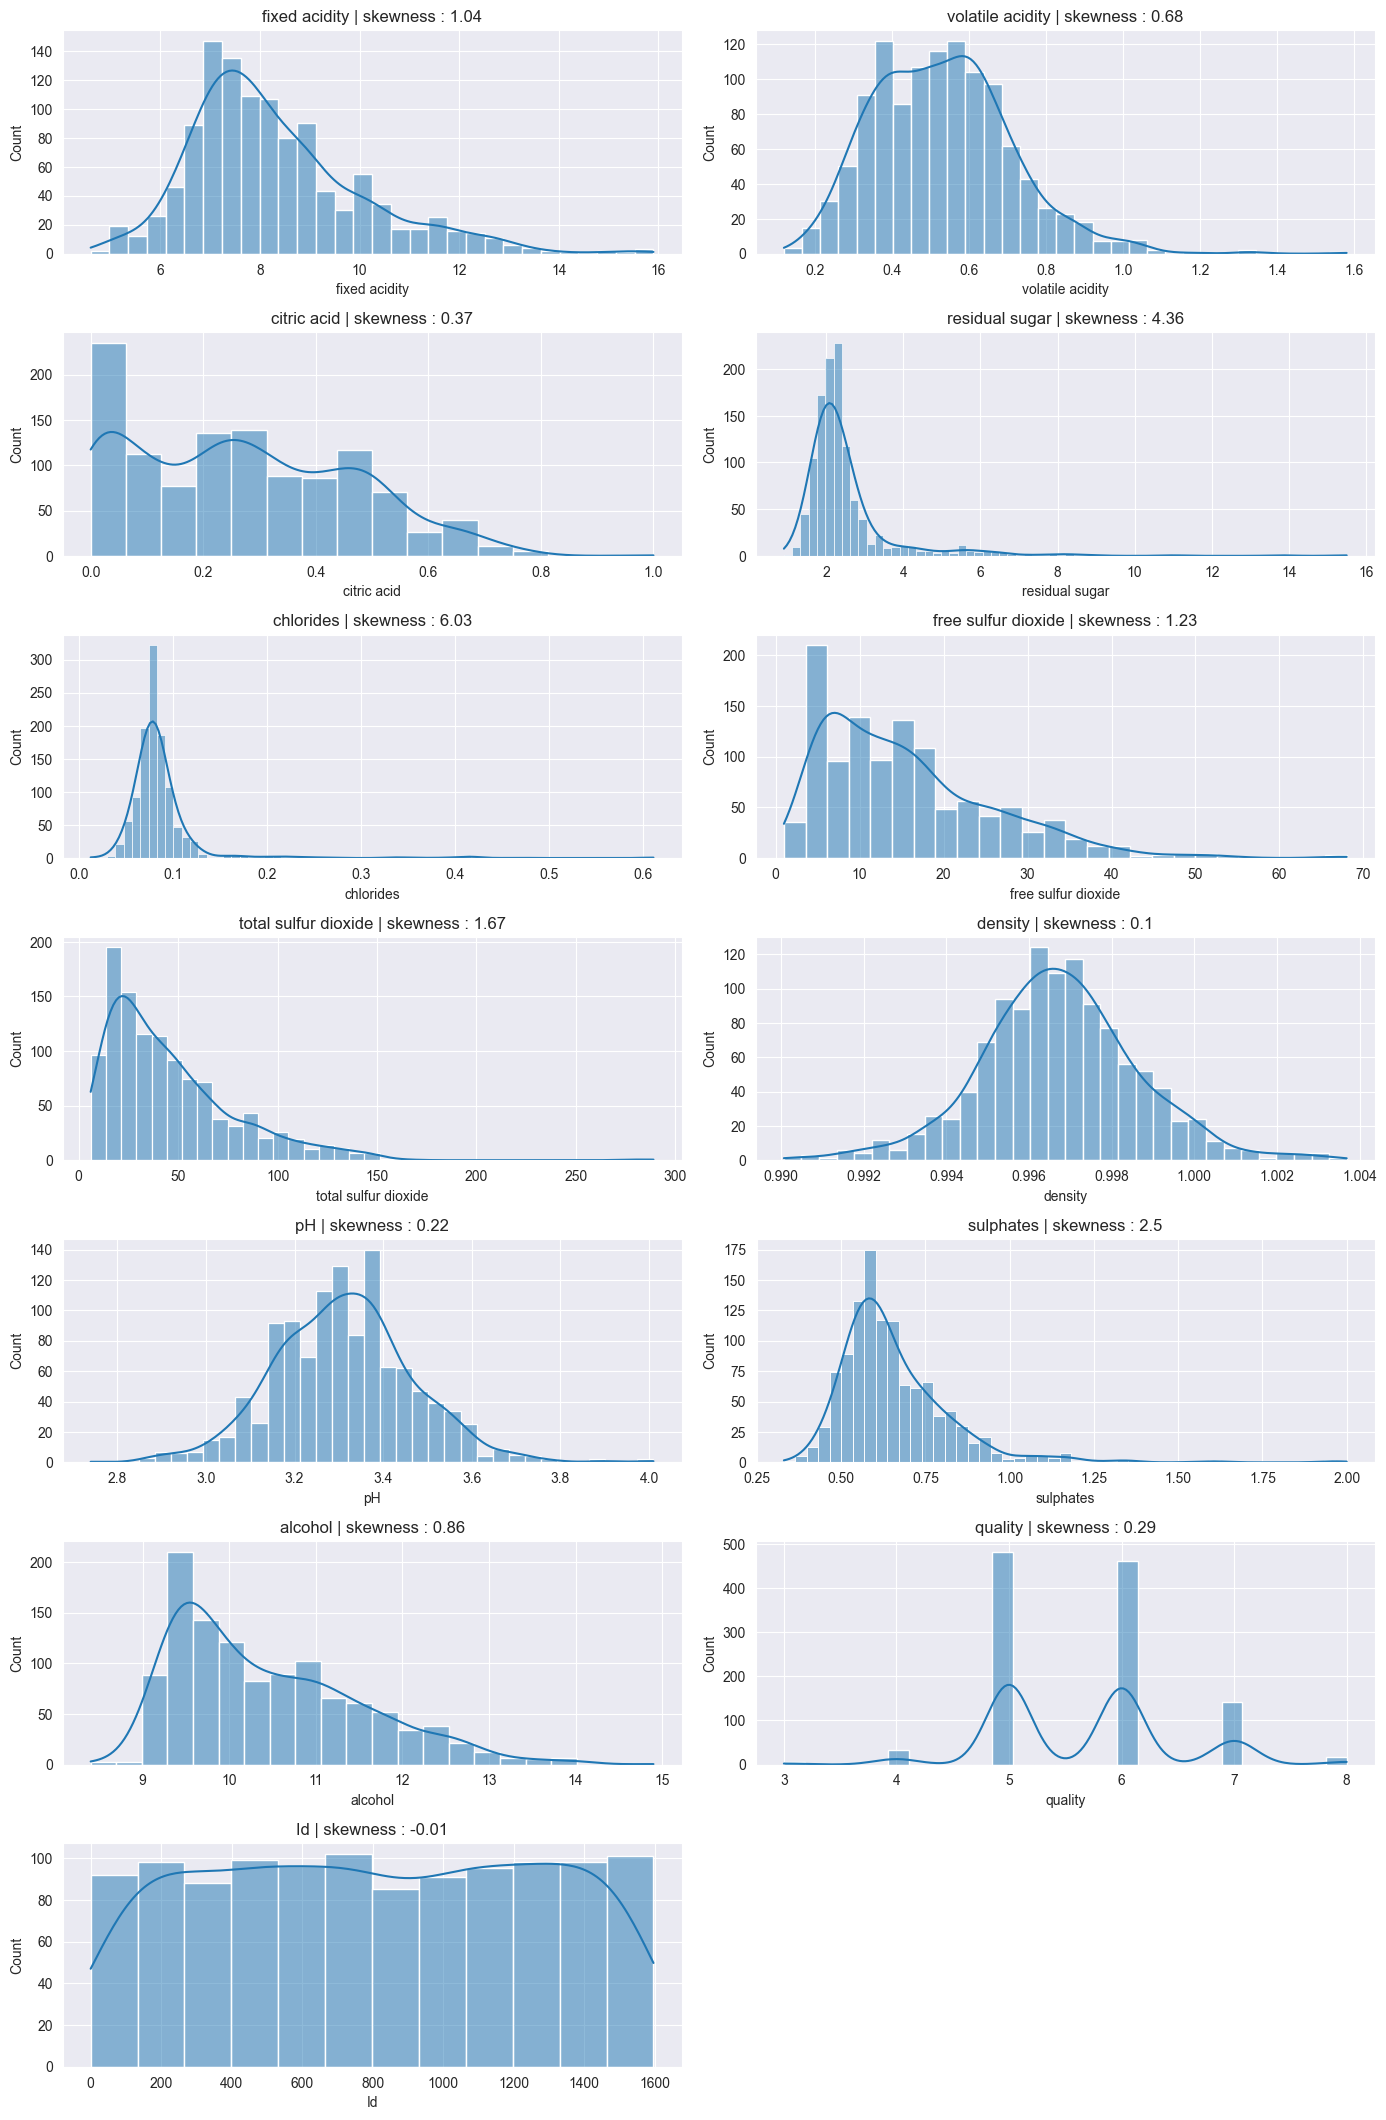

In [10]:
sns.set_style("darkgrid")

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(14, len(numerical_columns)*3))

for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | skewness : {round(df[feature].skew(),2)}")

plt.tight_layout()

plt.show()


SWARMP PLOT

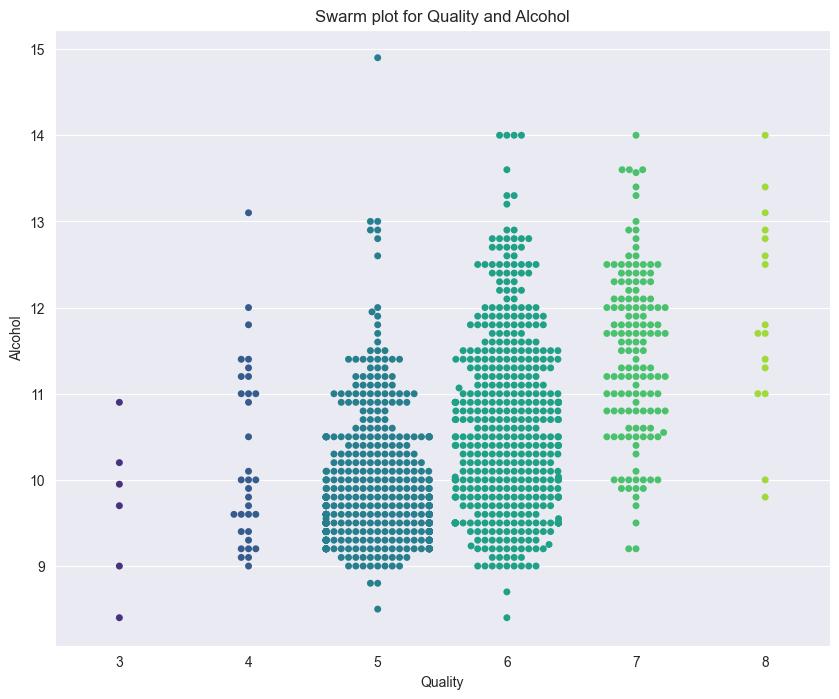

<Figure size 1000x600 with 0 Axes>

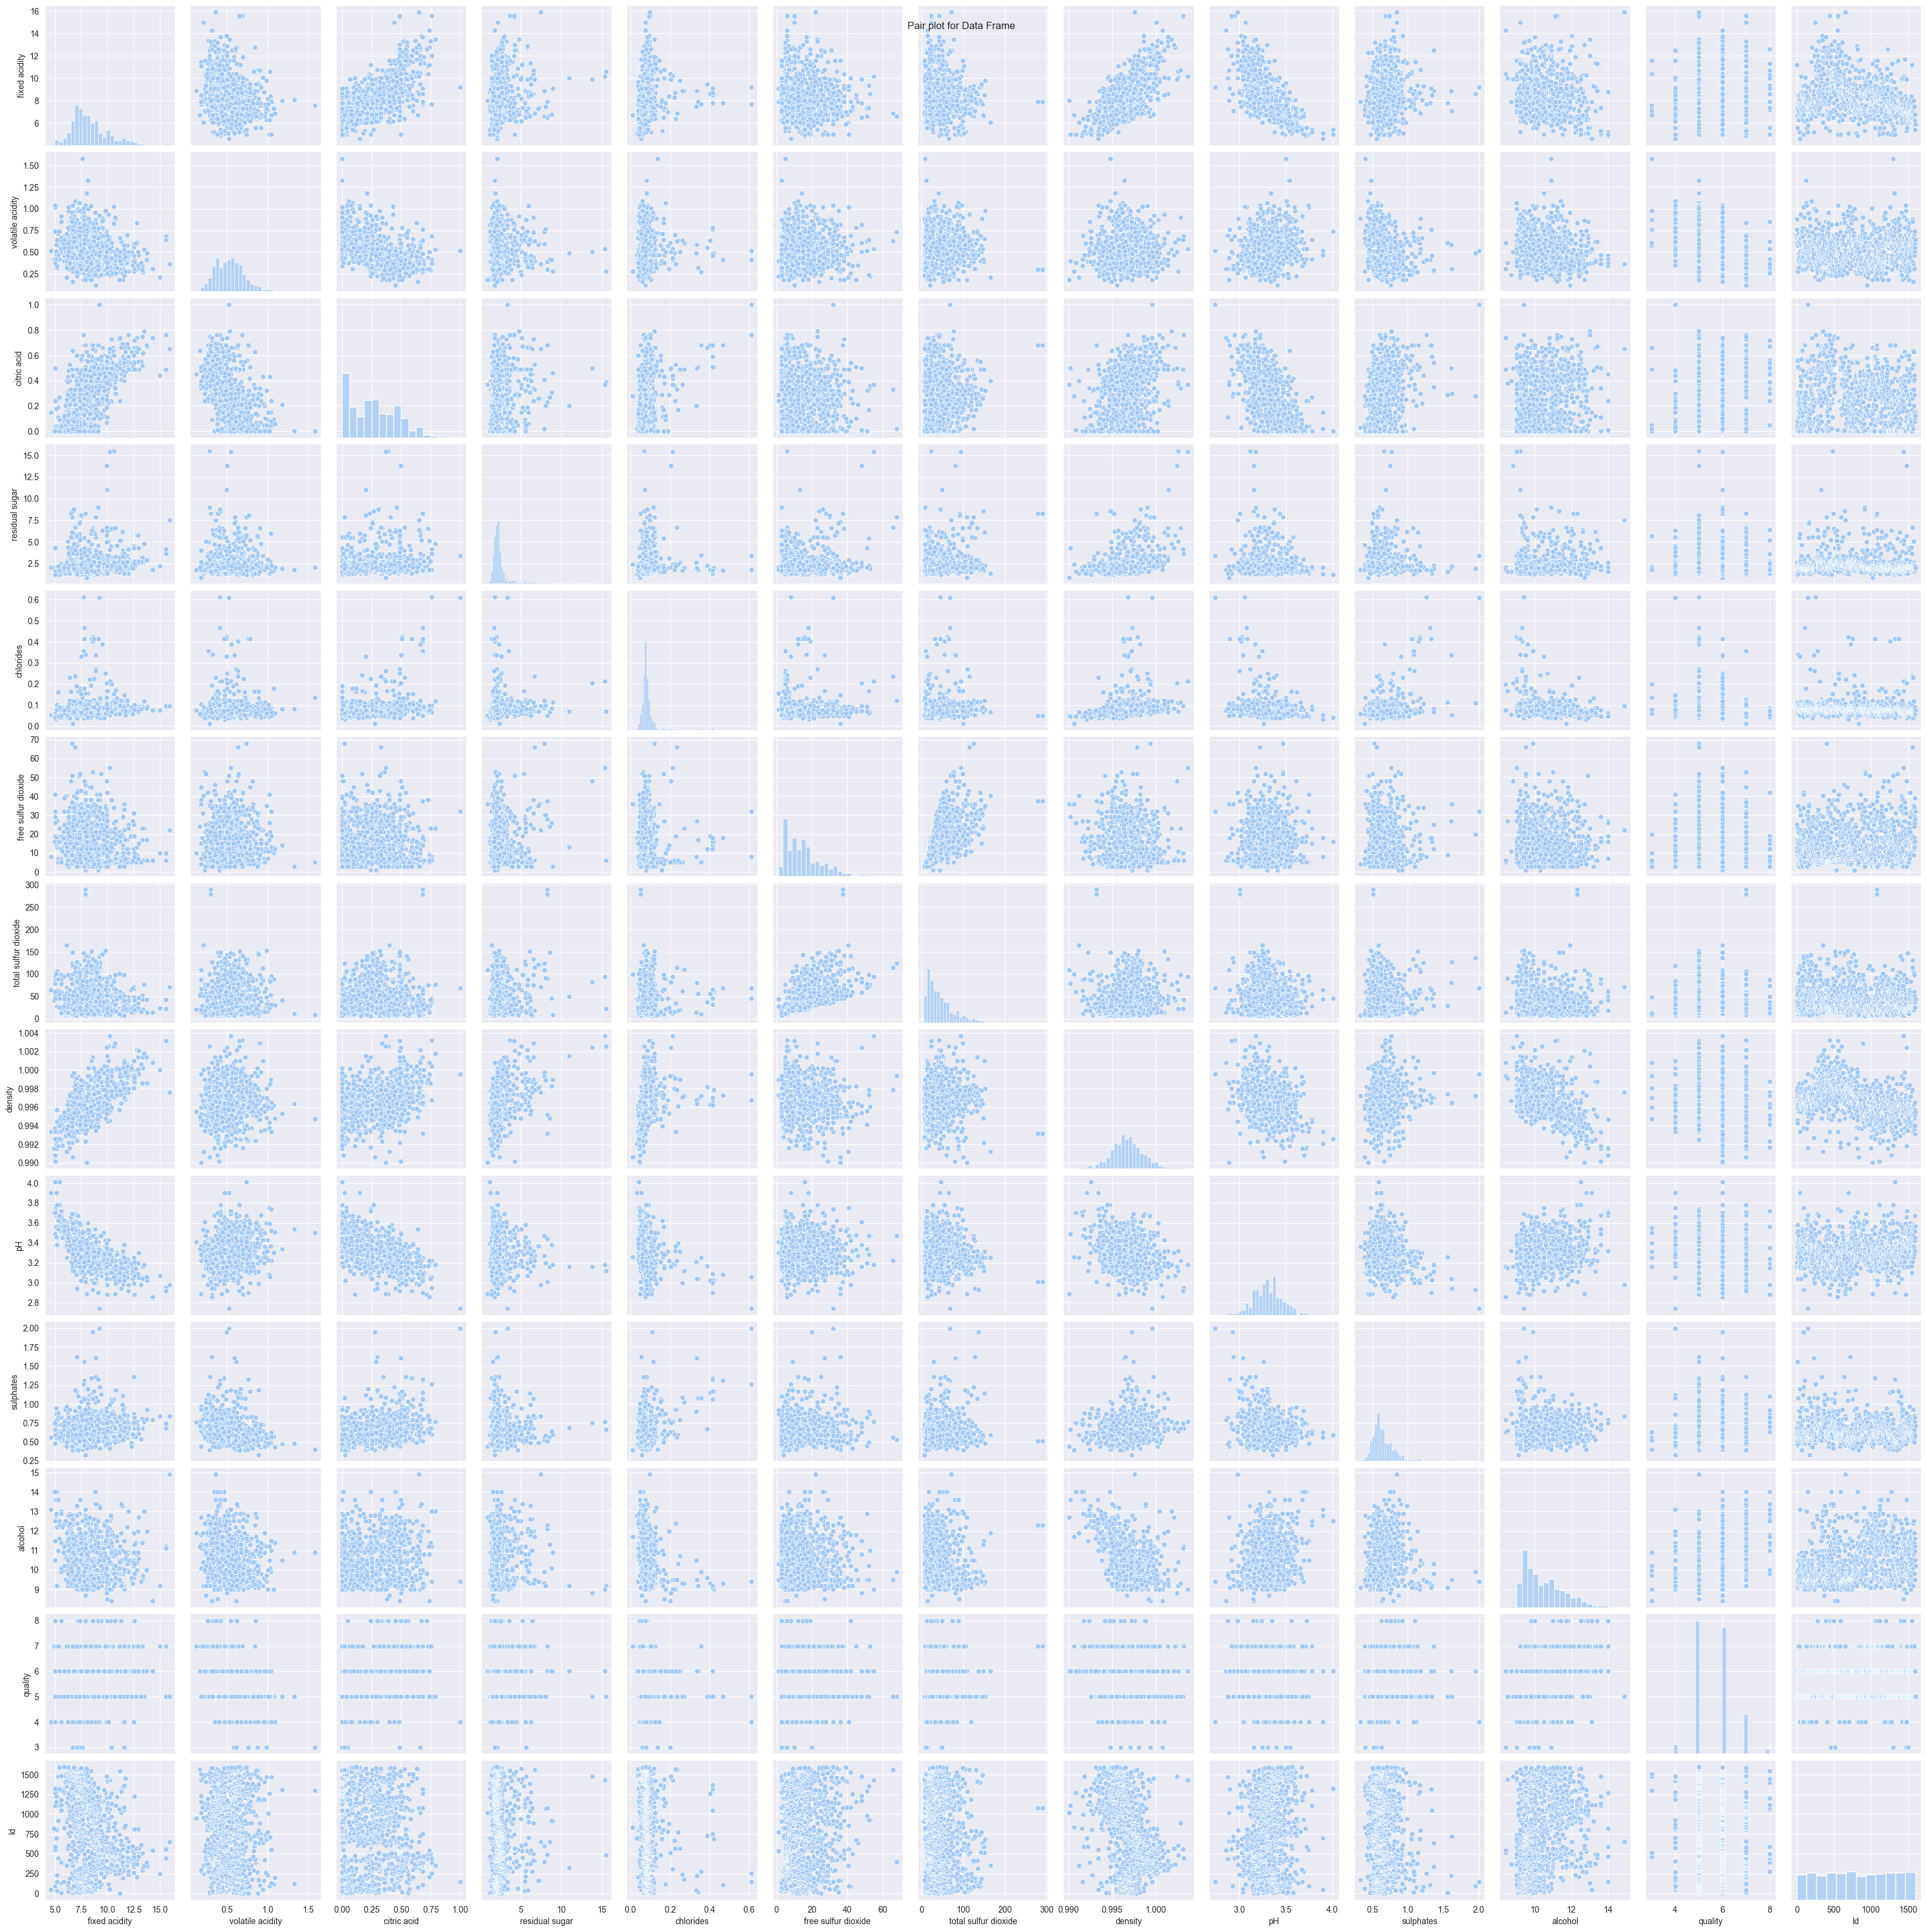

In [11]:
plt.figure(figsize=(10,8))

sns.swarmplot(x='quality', y='alcohol', data=df, palette='viridis')

plt.title('Swarm plot for Quality and Alcohol')

plt.xlabel('Quality')
plt.ylabel('Alcohol')

plt.show()

sns.set_palette("pastel")

plt.figure(figsize=(10,6))

sns.pairplot(df)

plt.suptitle('Pair plot for Data Frame')

plt.show()

<Axes: xlabel='quality', ylabel='alcohol'>

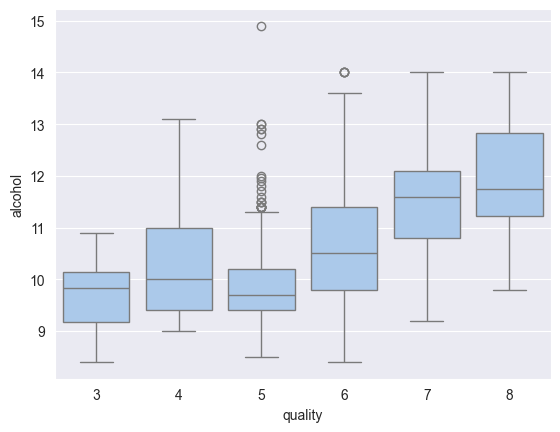

In [ ]:
sns.boxplot(x='quality', y='alcohol', data=df)s

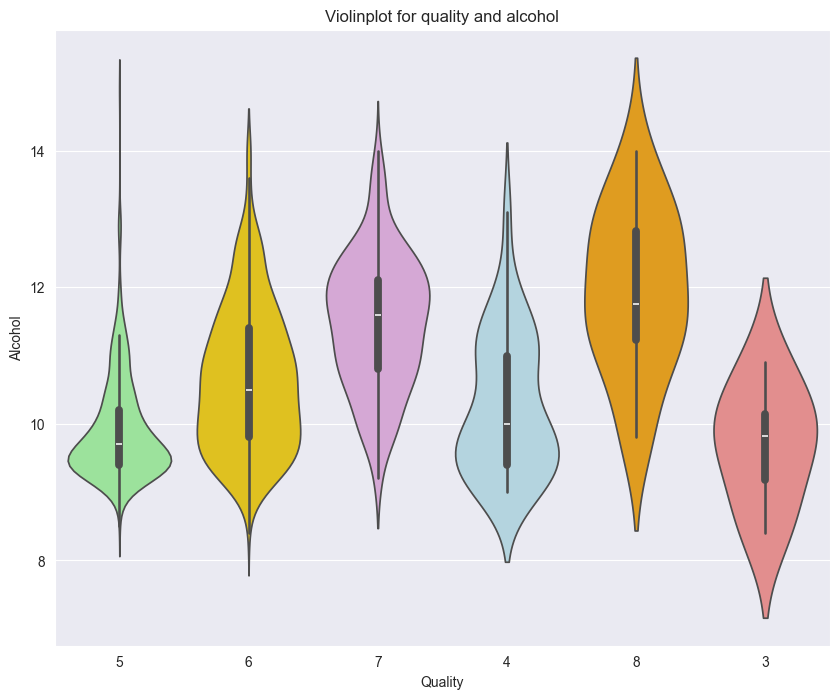

In [13]:
df['quality'] = df['quality'].astype(str)

# Set figure size
plt.figure(figsize=(10,8))

# Create violin plot
sns.violinplot(
    x='quality',
    y='alcohol',
    data=df,
    palette={
        '3':'lightcoral',
        '4':'lightblue',
        '5':'lightgreen',
        '6':'gold',
        '7':'plum',
        '8':'orange'
    }
)

# Add title and labels
plt.title('Violinplot for quality and alcohol')
plt.xlabel('Quality')
plt.ylabel('Alcohol')

# Show plot
plt.show()